# Neural Network Movie Recommendation and Rating Prediction

This is a deep learning-based movie recommendation system built with PyTorch using the MovieLens 100K dataset. This project uses Neural Collaborative Filtering with learned user and movie embeddings and a Hybrid Recommendation utilizing genres to predict movie ratings and generate personalized recommendations.

Instead of utilizing similarity metrics or matrix factorization techniques, a neural network is trained to learn underlying representations/embeddings for users and movies directly from rating data. The model predicts how a user would rate a movie and uses those predictions to recommend movies the user hasn't seen yet. The recommendation system scores unseen movies and recommends the highest-rated candidates.

In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim

import pandas as pd

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

C:\Users\kdona\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\kdona\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## Movie Rating Prediction
First, a network will be trained to predict what rating a user will give a movie. This prediction is based off the user's ratings, the ratings other users have given the movie, and ratings of users with similar ratings.

### Data
MovieLens 100K dataset
- u.data: training data
- u.item: maps movie IDs to movie names
- u.user: user info

Stats:
- 100,000 ratings
- 943 users
- 1,682 movies
- Ratings from 1 to 5 stars

In [45]:
ratings = pd.read_csv(
    "data/ml-100k/u.data", 
    sep="\t", 
    names=["user_id", "movie_id", "rating", "timestamp"]
)
print(ratings.head())

   user_id  movie_id  rating  timestamp
0      196       242       3  881250949
1      186       302       3  891717742
2       22       377       1  878887116
3      244        51       2  880606923
4      166       346       1  886397596


In [46]:
print("Dataset Shape:", ratings.shape)
print("\nUnique Users:", ratings["user_id"].nunique())
print("\nUnique Movies:", ratings["movie_id"].nunique())
print("\nRatings Distribution:", ratings["rating"].value_counts().sort_index())

Dataset Shape: (100000, 4)

Unique Users: 943

Unique Movies: 1682

Ratings Distribution: rating
1     6110
2    11370
3    27145
4    34174
5    21201
Name: count, dtype: int64


In [47]:
# Convert IDs to embedding indices
user_ids = ratings["user_id"].unique()
movie_ids = ratings["movie_id"].unique()

user_to_idx = {user_id: idx for idx, user_id in enumerate(user_ids)}
movie_to_idx = {movie_id: idx for idx, movie_id in enumerate(movie_ids)}

ratings["user_idx"] = ratings["user_id"].map(user_to_idx)
ratings["movie_idx"] = ratings["movie_id"].map(movie_to_idx)

ratings.head()

,user_id,movie_id,rating,timestamp,user_idx,movie_idx
0,196,242,3,881250949,0,0
1,186,302,3,891717742,1,1
2,22,377,1,878887116,2,2
3,244,51,2,880606923,3,3
4,166,346,1,886397596,4,4


In [48]:
print("Users:", ratings["user_idx"].nunique())
print("Movies:", ratings["movie_idx"].nunique())

print("\nMin user index:", ratings["user_idx"].min())
print("Max user index:", ratings["user_idx"].max())

print("\nMin movie index:", ratings["movie_idx"].min())
print("Max movie index:", ratings["movie_idx"].max())

Users: 943
Movies: 1682

Min user index: 0
Max user index: 942

Min movie index: 0
Max movie index: 1681


### Create Train/Test Split and Convert to Tensors
PyTorch Tensors are how neural networks understand data as opposed to NumPy arrays.

In [49]:
# Create train/test split and pytorch dataset
X = ratings[["user_idx", "movie_idx"]]
y = ratings["rating"]

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 80000
Testing samples: 20000


In [51]:
# Convert to PyTorch Tensors
X_train_tensor = torch.tensor(X_train.values, dtype=torch.long)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.long)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

In [52]:
# X_train_tensor -> Rows, features
# Features: [user_idx, movie_idx], Target: rating
print(X_train_tensor.shape, y_train_tensor.shape)

print(X_train_tensor[:5])

torch.Size([80000, 2]) torch.Size([80000])
tensor([[ 46, 355],
        [471,  81],
        [ 38, 544],
        [396, 317],
        [192, 104]])


### Create PyTorch Dataset and DataLoader
Neural networks typically don't train on all examples at once. They process small batches instead. PyTorch uses Dataset and DataLoader to handle this automatically.

Benefits: Faster training, lower memory usage, and more stable learning

In [53]:
# Create custom dataset
class MovieDataset(Dataset):
    def __init__(self, X, y): # Stores X and y inside the dataset
        self.X = X
        self.y = y

    def __len__(self): # Returns 80000 for training data
        return len(self.X)

    def __getitem__(self, idx): # Get single example -> ([user_idx, movie_idx], rating)
        return self.X[idx], self.y[idx]


In [54]:
# Create training and test datasets
train_data = MovieDataset(X_train_tensor, y_train_tensor)
test_data = MovieDataset(X_test_tensor, y_test_tensor)

In [55]:
# Create DataLoaders
train_loader = DataLoader(train_data, batch_size=256, shuffle=True)
test_loader = DataLoader(test_data, batch_size=256, shuffle=False)

In [56]:
# Inspect a batch
batch_X, batch_y = next(iter(train_loader))
print(batch_X.shape, batch_y.shape)

torch.Size([256, 2]) torch.Size([256])


In [57]:
print(batch_X[:5], "\n", batch_y[:5])

tensor([[ 841,  403],
        [ 181,  895],
        [ 736,   34],
        [ 453, 1036],
        [  19,  688]]) 
 tensor([3., 4., 4., 5., 4.])


### Neural Collaborative Filtering vs. Hybrid Recommendation Models
<b>Collaborative Filtering Flow:</b> <br>
User ID -> User Embedding <br>
Movie ID -> Movie Embedding <br>
User + Movie Embeddings -> Concatenate -> Dense Layer -> ReLU -> Dense Layer -> Predicted Rating <br>

<b>Hybrid Recommendation Flow:</b> <br>
User ID -> User Embedding <br>
Movie ID -> Movie Embedding <br>
Genre Features <br>
User Embeddings + Movie Embeddings + Genre Features -> Concatenate -> Dense Layer -> ReLU -> Dense Layer -> Predicted Rating <br>

Multiple layers allows the model to learn more complex relationships.

Embeddings are what the network uses to learn. It's translating unordered user and movie IDs into learned vectors.

The fully connected layers (fc1, fc2) are where the network learns.

Rectified Linear Unit (ReLU) is an activation function that introduces non-linearity and allows the network to learn much more complex patterns. 

#### Collaborative Filtering Model

In [58]:
# Create collaborative filtering model
class MovieRecommender(nn.Module):
    def __init__(self, num_users, num_movies, embedding_dim=50):
        super().__init__()

        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.movie_embedding = nn.Embedding(num_movies, embedding_dim)

        # Dense layers
        # Each fully connected layer maps every input to an output (neuron)
        self.fc1 = nn.Linear(embedding_dim * 2, 128) # layer 1 that turns 100 embeddings into 128 neurons
        self.fc2 = nn.Linear(128, 64) # layer 2 that turns 128 inputs into 64 neurons
        self.output = nn.Linear(64, 1) # final layer that turns 64 inputs into 1 output (predicted rating)

        # Introduces non-linearity, allowing network to learn more complex patterns
        self.relu = nn.ReLU() 
        # Remove negative values -> clip to 0

    def forward(self, x): # Transform inputs into a prediction
        user_ids = x[:, 0]
        movie_ids = x[:, 1] 

        # Embedding
        user_embeds = self.user_embedding(user_ids)
        movie_embeds = self.movie_embedding(movie_ids)

        # Concatenation 
        # combine user and movie embeds
        # shape now [256, 100]
        x = torch.cat([user_embeds, movie_embeds], dim=1)
        
        x = self.relu(self.fc1(x)) # Dense layer 1, remove negatives
        x = self.relu(self.fc2(x)) # Dense layer 2, remove negatives

        return self.output(x).squeeze() # adjusting shape from [256, 1] to [256]

In [59]:
num_users = ratings["user_idx"].nunique()
num_movies = ratings["movie_idx"].nunique()

model1 = MovieRecommender(num_users = num_users, num_movies = num_movies)
print(model1)

MovieRecommender(
  (user_embedding): Embedding(943, 50)
  (movie_embedding): Embedding(1682, 50)
  (fc1): Linear(in_features=100, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (output): Linear(in_features=64, out_features=1, bias=True)
  (relu): ReLU()
)


In [60]:
batch_X, batch_y = next(iter(train_loader))
predictions = model1(batch_X)
print(predictions.shape)
print(predictions[:5])

torch.Size([256])
tensor([-0.0737,  0.0003, -0.1492, -0.1240, -0.1298], grad_fn=<SliceBackward0>)


#### Train Neural Network
Process:
1. Make predictions
2. Measure how wrong they are
3. Adjust weights slightly
4. Repeat thousands of times

It's important to measure how wrong the model is (loss) so it can be improved. An optimizer is also used to improve the model with each iteration and help it learn. By keeping track of loss with a loss function, such as Mean Squared Error (MSE), we can see how well the network is learning.

In [61]:
# Optimizer -> updates model's weights
# Figures out how to improve the model after each mistake
optimizer = optim.Adam(model1.parameters(), lr=0.001)

In [62]:
# Training Loop
num_epochs = 5

# Loss function -> need a way to measure error -> MSE
criterion = nn.MSELoss()

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for batch_X, batch_y in train_loader:
        # Zero the gradients
        optimizer.zero_grad() # clears previous calculations
        # Make predictions
        predictions = model1(batch_X) # network guesses ratings
        # Calculate error
        loss = criterion(predictions, batch_y) # measures how wrong those guesses are
        # Backpropagation
        # PyTorch calcs 'which weights caused the error?' and 'how should each weight change?' automatically
        loss.backward() 
        
        # Update model
        optimizer.step() # adjust all weights and embeddings slightly

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(
        f"Epoch {epoch + 1}/{num_epochs}, "
        f"Loss: {avg_loss:.4f}" # it's important that loss decreases -> means model is learning
    )


Epoch 1/5, Loss: 1.7951
Epoch 2/5, Loss: 1.0077
Epoch 3/5, Loss: 0.9296
Epoch 4/5, Loss: 0.8877
Epoch 5/5, Loss: 0.8584


The loss decrease from an initial 1.7951 to 0.8585 indicates that the network is learning.

#### Evaluate Model
Training loss tells how well the model learned from the training data. Test loss tells how well it generalizes to unseen data.

In [63]:
# switch from training to testing mode
model1.eval()

total_test_loss = 0

# Gradients aren't necessary, makes evaluation faster and uses less memory
with torch.no_grad(): 
    for batch_X, batch_y in test_loader:
        predictions = model1(batch_X)

        loss = criterion(predictions, batch_y)

        total_test_loss += loss.item()

avg_test_loss = total_test_loss / len(test_loader)
print(f"Test Loss: {avg_test_loss:.4f}")

Test Loss: 0.9475


In [64]:
batch_X, batch_y = next(iter(test_loader))
with torch.no_grad():
    predictions = model1(batch_X)

for i in range(10):
    print(
        f"Actual: {batch_y[i].item():.1f}, "
        f"Predicted: {predictions[i].item():.2f}"
    )

Actual: 4.0, Predicted: 3.63
Actual: 1.0, Predicted: 3.36
Actual: 4.0, Predicted: 3.83
Actual: 3.0, Predicted: 3.27
Actual: 1.0, Predicted: 2.63
Actual: 4.0, Predicted: 3.79
Actual: 3.0, Predicted: 4.66
Actual: 4.0, Predicted: 3.94
Actual: 2.0, Predicted: 2.93
Actual: 4.0, Predicted: 3.65


#### Hybrid Recommendation Model 

In [65]:
# Data + genres
movies_raw = pd.read_csv(
    "data/ml-100k/u.item",
    sep="|",
    encoding="latin-1",
    header=None
)

genre_columns = [
    "unknown",
    "Action",
    "Adventure",
    "Animation",
    "Children",
    "Comedy",
    "Crime",
    "Documentary",
    "Drama",
    "Fantasy",
    "Film-Noir",
    "Horror",
    "Musical",
    "Mystery",
    "Romance",
    "Sci-Fi",
    "Thriller",
    "War",
    "Western"
]

movies_genres = movies_raw[
    [0, 1] + list(range(5, 24))
].copy()
movies_genres.columns = (["movie_id", "title"] + genre_columns)
movies_genres.head()

,movie_id,title,unknown,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),0,0,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),0,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0


In [71]:
ratings_genres = ratings.merge(movies_genres, on = "movie_id", how = "left")
feature_columns = (["user_idx", "movie_idx"] + genre_columns)
X = ratings_genres[feature_columns]
y = ratings_genres["rating"]
# print(X.shape)
# print(X.head())

#### Train/Test Split and Tensors

In [73]:
# New train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 10
)

In [74]:
# Create new tensors
X_train_tensor = torch.tensor(X_train.values, dtype = torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype = torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype = torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype = torch.float32)

#### New Model to Include Genres

In [75]:
class HybridMovieRecommender(nn.Module):
    def __init__(
        self,
        num_users,
        num_movies,
        embedding_dim=50,
        num_genres=19
    ):
        super().__init__()

        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.movie_embedding = nn.Embedding(num_movies, embedding_dim)
        self.fc1 = nn.Linear(embedding_dim * 2 + num_genres, 128)
        self.fc2 = nn.Linear(128, 64)
        self.output = nn.Linear(64, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        user_ids = x[:, 0].long()
        movie_ids = x[:, 1].long()
        genres = x[:, 2:]

        user_embeds = self.user_embedding(user_ids)
        movie_embeds = self.movie_embedding(movie_ids)

        # Now 50 user features + 50 movie features + 19 genre features = 119 inputs
        x = torch.cat(
            [
                user_embeds,
                movie_embeds,
                genres
            ],
            dim = 1
        )

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))

        return self.output(x).squeeze()

#### Train Model

In [76]:
# Create and train new model
model2 = HybridMovieRecommender(num_users = num_users, num_movies = num_movies)

criterion = nn.MSELoss()
optimizer = optim.Adam(model2.parameters(), lr = 0.001)

# Create training and test datasets
train_data = MovieDataset(X_train_tensor, y_train_tensor)
test_data = MovieDataset(X_test_tensor, y_test_tensor)
# Create DataLoaders
train_loader = DataLoader(train_data, batch_size=256, shuffle=True)
test_loader = DataLoader(test_data, batch_size=256, shuffle=False)

In [77]:
# Training Loop
num_epochs = 5

for epoch in range(num_epochs):
    model2.train()
    total_loss = 0

    for batch_X, batch_y in train_loader:
        # Zero the gradients
        optimizer.zero_grad() # clears previous calculations
        # Make predictions
        predictions = model2(batch_X) # network guesses ratings
        # Calculate error
        loss = criterion(predictions, batch_y) # measures how wrong those guesses are
        # Backpropagation
        # PyTorch calcs 'which weights caused the error?' and 'how should each weight change?' automatically
        loss.backward() # deep learning magic

        # Update model
        optimizer.step() # adjust all weights and embeddings slightly

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(
        f"Epoch {epoch + 1}/{num_epochs}, "
        f"Loss: {avg_loss:.4f}" # it's important that loss decreases -> means model is learning
    )


Epoch 1/5, Loss: 1.8551
Epoch 2/5, Loss: 0.9888
Epoch 3/5, Loss: 0.9170
Epoch 4/5, Loss: 0.8757
Epoch 5/5, Loss: 0.8492


In [78]:
model2.eval()

total_test_loss = 0

with torch.no_grad(): 
    for batch_X, batch_y in test_loader:
        predictions = model(batch_X)

        loss = criterion(predictions, batch_y)

        total_test_loss += loss.item()

avg_test_loss = total_test_loss / len(test_loader)
print(f"Test Loss: {avg_test_loss:.4f}")

batch_X, batch_y = next(iter(test_loader))
with torch.no_grad():
    predictions = model2(batch_X)

for i in range(10):
    print(
        f"Actual: {batch_y[i].item():.1f}, "
        f"Predicted: {predictions[i].item():.2f}"
    )

Test Loss: 0.9431
Actual: 4.0, Predicted: 3.84
Actual: 1.0, Predicted: 3.18
Actual: 4.0, Predicted: 3.93
Actual: 3.0, Predicted: 3.58
Actual: 1.0, Predicted: 2.73
Actual: 4.0, Predicted: 3.11
Actual: 3.0, Predicted: 4.72
Actual: 4.0, Predicted: 3.92
Actual: 2.0, Predicted: 2.75
Actual: 4.0, Predicted: 3.83


Very minimal to no change in rating prediction with 5 epochs.

Additional training with 20 epochs resulted in overfitting. The training loss decreased from 0.8463 to 0.5505, but the test loss increased from 0.9431 to 1.0808. Embeddings may have already captured much of the genre info implicitly from user behavior, which is often more beneficial than broad genre labels.

## Visualize Movie Embeddings with t-SNE
Movie embeddings are visualized using t-SNE to better understand the representations learned by the network.

This visualization will be created using the hybrid model.

In [98]:
# Extract movie embeddings
# Getting a learned movie matrix, removing it from the PyTorch gradient-tracking system,
# and converting to a NumPy array
movie_embeddings = model2.movie_embedding.weight.detach().numpy()
print(movie_embeddings.shape)

(1682, 50)


In [93]:
tsne = TSNE(n_components = 2, random_state = 10, perplexity = 30)
movie_2d = tsne.fit_transform(movie_embeddings)
print(movie_2d.shape)

(1682, 2)


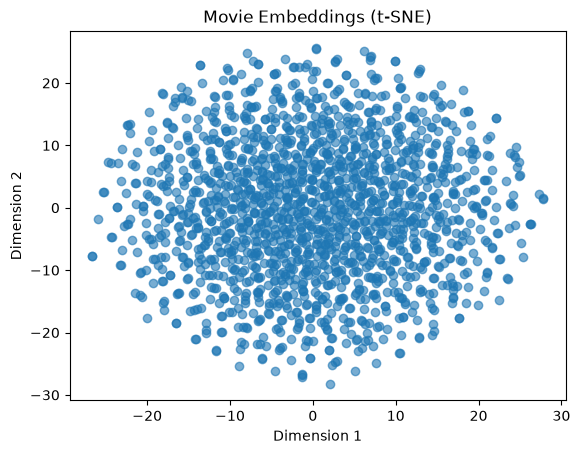

In [94]:
# Plot
plt.scatter(movie_2d[:, 0], movie_2d[:, 1], alpha = 0.6)
plt.title("Movie Embeddings (t-SNE)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()

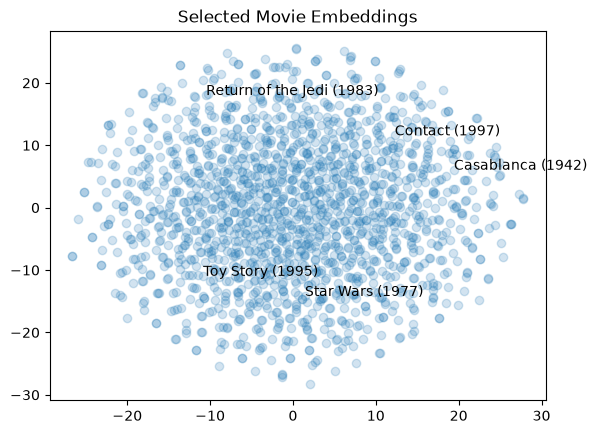

In [96]:
# Label movies

# Create lookup dict
movie_id_to_title = dict(
    zip(movies_genres["movie_id"], movies_genres["title"])
)

# Reverse mapping -> convert embedding index to original movie ID
idx_to_movie = {
    idx: movie_id
    for movie_id, idx in movie_to_idx.items()
}

interesting_movies = [
    "Star Wars (1977)",
    "Return of the Jedi (1983)",
    "Toy Story (1995)",
    "Contact (1997)",
    "Casablanca (1942)"
]

# Plot
plt.scatter(movie_2d[:, 0], movie_2d[:, 1], alpha = 0.2)

for idx, movie_id in idx_to_movie.items():
    title = movie_id_to_title.get(movie_id)
    if title in interesting_movies:
        plt.annotate(title, (movie_2d[idx, 0], movie_2d[idx, 1]))
plt.title("Selected Movie Embeddings")
plt.show()

Although some clusters appeared, movies from the same franchise were not always located near one another, suggesting that the embeddings learned user-rating relationships rather than traditional genre or franchise-based similarity.

## Movie Recommendations
Now a recommendation function utilizing cosine similarity can be created to recommend new movies to users based off ratings. The goal is to find similar movies using embeddings. An embedding vector for one movie will be compared to all other movie embeddings to find the most similar movies.

The hybrid model will be used to find movie recommendations.

In [100]:
# Create movie lookup dictionary
movie_title_to_id = dict(
    zip(movies_genres["title"], movies_genres["movie_id"])
)

In [101]:
# Create similar movie function (using cosine similarity)
def find_similar_movies(movie_title, top_n=10):
    movie_id = movie_title_to_id[movie_title]
    movie_idx = movie_to_idx[movie_id]
    embeddings = model.movie_embedding.weight.detach().numpy()
    target_embedding = embeddings[movie_idx].reshape(1, -1)

    similarities = cosine_similarity(target_embedding, embeddings)[0]

    # sort values and return indices from largest to smallest
    top_indices = similarities.argsort()[::-1] 

    results = []
    for idx in top_indices[1:top_n+1]:
        similar_movie_id = idx_to_movie[idx]
        title = movie_id_to_title[similar_movie_id]
        similarity = similarities[idx]

        results.append((title, similarity))

    return results

In [102]:
find_similar_movies("Star Wars (1977)")

[('My Favorite Season (1993)', 0.47701573),
 ("Joe's Apartment (1996)", 0.4012302),
 ('Apple Dumpling Gang, The (1975)', 0.39049777),
 ('Buddy (1997)', 0.35818362),
 ('Good, The Bad and The Ugly, The (1966)', 0.3527982),
 ('Manon of the Spring (Manon des sources) (1986)', 0.3486047),
 ('Boys Life (1995)', 0.34658977),
 ('Ma vie en rose (My Life in Pink) (1997)', 0.3453226),
 ('Menace II Society (1993)', 0.34471023),
 ('Herbie Rides Again (1974)', 0.3426315)]

The model was optimized for rating, prediction, and accuracy, not genre, franchise, or plot similarity.

People who highly rate Star Wars also highly rated My Favorite Season is useful for predicting ratings, but not for predicting movie similarity. However, this list may still be useful to someone looking for new genres to watch but want a recommendation based on previous movies enjoyed.

Even with adding genres for the network to train on, the model still recommends movies highly rated by users who also highly rated Star Wars.